<a href="https://colab.research.google.com/github/zpsy-hub/Machine-Learning-and-Predictive-Analytics/blob/main/Machine_Learning_MS_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries and Reading Data**
Load the necessary tools and functions that will be used throughout the analysis.

In [47]:
# Data Manipulation & Analysis
import pandas as pd  # For handling and manipulating structured data
import numpy as np  # For numerical operations and handling arrays

# Data Visualization
import matplotlib.pyplot as plt  # For static plots
import seaborn as sns  # For statistical visualizations (built on Matplotlib)
import plotly.express as px  # For interactive visualizations

# Statistical Analysis
import scipy.stats as stats  # For statistical functions like hypothesis testing
from scipy.stats import skew, kurtosis  # For distribution skewness & kurtosis

# Machine Learning - Preprocessing & Feature Engineering
from sklearn.model_selection import train_test_split  # Splitting data into training and testing sets
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # Feature scaling
from sklearn.preprocessing import OneHotEncoder, LabelEncoder  # Encoding categorical variables
from sklearn.impute import SimpleImputer  # Handling missing values
from sklearn.pipeline import Pipeline  # Automating ML workflows
from sklearn.compose import ColumnTransformer  # Handling numerical & categorical transformations

# Machine Learning - Modeling
from sklearn.linear_model import LogisticRegression  # For classification tasks
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Tree-based models
from xgboost import XGBClassifier  # Gradient boosting model for high performance
from sklearn.neural_network import MLPClassifier  # Multi-layer perceptron (simple neural network)
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.tree import DecisionTreeClassifier  # Decision tree model
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier  # Ensemble methods

# Model Evaluation & Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix  # Model evaluation metrics
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV  # Model tuning and validation

# Feature Selection & Importance
from sklearn.feature_selection import SelectKBest, chi2, RFE  # Feature selection methods
from sklearn.inspection import permutation_importance  # Feature importance evaluation
import shap  # SHAP for explainable AI (model interpretation)

# Model Deployment & Integration
import pickle  # Saving and loading trained models
import joblib  # Efficient model serialization

# Display DataFrames nicely in Jupyter/Colab
from IPython.display import display

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

!pip install tabulate # Install the tabulate library
from tabulate import tabulate # Import the tabulate function
from dateutil import parser  # Import the parser module from dateutil


Load the dataset into memory so we can work with it and start analyzing the data.

In [48]:
df_customers = pd.read_csv("/content/drive/MyDrive/3rd year 2024-25/Term 2/Machine Learning and Predictive Analytics/raw data/customers_data.csv")
df_products = pd.read_csv("/content/drive/MyDrive/3rd year 2024-25/Term 2/Machine Learning and Predictive Analytics/raw data/products_data.csv")
df_transactions = pd.read_csv("/content/drive/MyDrive/3rd year 2024-25/Term 2/Machine Learning and Predictive Analytics/raw data/transactions_data.csv")

# **Data Overview**

Understanding the initial structure and quality of the data helps identify potential issues (like missing values or inconsistencies) before starting the cleaning process.

Load the 3 datasets into a dictionary, allowing us to loop through them in the next steps.

In [49]:
# Dictionary of DataFrames
dfs = {
    "customers": df_customers,
    "products": df_products,
    "transactions": df_transactions
}

### **Summary Statistics**

`describe()` provides a summary of the data, showing key statistics like mean, standard deviation, min, and max values for numerical columns.

It helps quickly understand the distribution and general characteristics of the data, which is useful for identifying any potential outliers or issues before cleaning.

In [50]:
for name, df in dfs.items():
    print(f"{name}:\n{df.describe()}\n")

customers:
       Company_ID  Company_Profit
count   90.000000       88.000000
mean    51.944444    76400.500000
std     28.684397    27296.169253
min      1.000000    30663.000000
25%     27.500000    52648.500000
50%     53.500000    75301.500000
75%     76.750000   101089.750000
max    100.000000   118114.000000

products:
       Product_ID
count   18.000000
mean    10.333333
std      6.077925
min      1.000000
25%      5.250000
50%     10.500000
75%     14.750000
max     20.000000

transactions:
        Unnamed: 0  Transaction_ID   Company_ID   Product_ID     Quantity  \
count  9000.000000     9000.000000  9000.000000  9000.000000  9000.000000   
mean   4994.049111     5005.177556    50.583556    10.446778    10.528778   
std    2885.331476     2894.971964    28.900870     5.768341     5.808062   
min       0.000000        1.000000     1.000000     1.000000     0.000000   
25%    2501.750000     2491.750000    25.000000     5.000000     6.000000   
50%    4997.500000     5005.00000

### **First 5 rows of each data set**


In [51]:
for name, df in dfs.items():
    print(f"{name}:\n{tabulate(df.head(10), headers='keys', tablefmt='psql')}\n")

customers:
+----+--------------+----------------------+------------------+-------------------------------------------------------+
|    |   Company_ID | Company_Name         |   Company_Profit | Address                                               |
|----+--------------+----------------------+------------------+-------------------------------------------------------|
|  0 |            1 | Tech  Enterprises  1 |            80701 | EDSA, Barangay 606, Pasig, Philippines                |
|  1 |            2 | Global  Partners  2  |            80511 | Commonwealth Ave, Barangay 789, Taguig, Philippines   |
|  2 |            3 | Quantum Associates 3 |           110664 | Roxas Blvd, Barangay 505, Pasig, Philippines          |
|  3 |            4 | Prime Network 4      |              nan | Alabang-Zapote Rd, Barangay 202, Taguig, Philippines  |
|  4 |            5 | Elite  Ventures  5   |            69427 | Ayala Avenue, Barangay 101, Makati, Philippines       |
|  5 |          nan | Elite N

### **Display Index, Columns, and Data**
`info()` provides an overview of the dataset, including the number of entries, column names, data types, and memory usage.

 It gives a quick check on the structure of the data, helping identify missing values and understanding the types of data you're working with before proceeding with analysis or cleaning.

In [52]:
for name, df in dfs.items():
  print(f"DataFrame Info for {name}:")
  df.info()
  print()

DataFrame Info for customers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company_ID      90 non-null     float64
 1   Company_Name    100 non-null    object 
 2   Company_Profit  88 non-null     float64
 3   Address         100 non-null    object 
dtypes: float64(2), object(2)
memory usage: 3.3+ KB

DataFrame Info for products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     18 non-null     float64
 1   Product_Name   20 non-null     object 
 2   Product_Price  20 non-null     object 
dtypes: float64(1), object(2)
memory usage: 612.0+ bytes

DataFrame Info for transactions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 colum

##**Observations after Cursory look at the data**

### **📂 Customers Data (`customers_data.csv`)**  
This dataset contains details about the companies, including unique identifiers, names, profits, and addresses.

</br>

**📝 Column Descriptions**

| Column Name       | Description                        | Data Type | Example Data                         |
|------------------|--------------------------------|-----------|--------------------------------------|
| **Company_ID**   | Unique identifier for the company | `float`   | 1                                    |
| **Company_Name** | Name of the company              | `object`  | Tech Enterprises 1                   |
| **Company_Profit** | Profit of the company         | `float`   | 80,701                                |
| **Address**      | Address of the company          | `object`  | EDSA, Barangay 606, Pasig, Philippines |


</br>
</br>

**🔎 Observations & Issues**
- **`Company_ID`**:  
  - Some IDs are missing, requiring reindexing in sequential order.  
  - Data type should be converted from `float` to `int` to remove decimal points.  

- **`Company_Name`**:  
  - Some names include a numeric suffix (e.g., "Tech Enterprises 1").  
  - If numbers are removed, there might be duplicate company names. Needs verification before cleaning.  

- **`Company_Profit`**:  
  - No currency indicator (e.g., USD, PHP).  
  - Requires validation to check if any negative profits (losses) exist.  

- **`Address`**:  
  - Variations in format (e.g., "Brngy" vs. "Barangay") need standardization.  
  - Capitalization inconsistencies should be corrected for uniformity.  

</br>
</br>

**🚀 Next Steps**

✔ Convert `Company_ID` to `int` and fill missing values sequentially.  
✔ Clean `Company_Name` by removing numeric suffixes and handling duplicates.  
✔ Confirm and specify the currency for `Company_Profit`.  
✔ Standardize `Address` formatting and capitalization.  


---




### **📂 Products Data (`products_data.csv`)**  
This dataset provides information about the company's products, including their unique identifiers, names, and prices.

</br>

**📝 Column Descriptions**

| Column Name       | Description                        | Data Type | Example Data               |
|------------------|--------------------------------|-----------|---------------------------|
| **Product_ID**   | Unique identifier for the product | `float`   | 1                         |
| **Product_Name** | Name of the product              | `object`  | FinPredictor Suite        |
| **Product_Price** | Price of the product           | `object`  | ?140,000                  |


</br>
</br>

**🔎 Observations & Issues**
- **`Product_ID`**:  
  - Some IDs are missing and should be filled sequentially.  

- **`Product_Name`**:  
  - No immediate issues detected.  

- **`Product_Price`**:  
  - No currency is specified (e.g., USD, PHP).  
  - Stored as an **object** instead of a numerical type. Needs conversion to `float` after cleaning.  
  - Some price values have inconsistent formatting (e.g., `?140,000`). Requires correction.  


</br>
</br>

**🚀 Next Steps**

✔ Convert `Product_ID` to `int` and fill missing values.  
✔ Standardize `Product_Price` formatting and convert to `float`.  
✔ Verify and specify the currency used for `Product_Price`.  


---




### **📂 Transactions Data (`transactions_data.csv`)**  
This dataset records individual transactions, including company and product details, quantities, prices, and timestamps.

</br>

**📝 Column Descriptions**

| Column Name         | Description                                    | Data Type | Example Data         |
|--------------------|--------------------------------|-----------|-------------------|
| **Unnamed: 0**     | Index of the row (can be dropped) | `float`   | 0                 |
| **Transaction_ID** | Unique identifier for the transaction | `float`   | 1                 |
| **Company_ID**     | Identifier of the purchasing company | `float`   | 88                |
| **Product_ID**     | Identifier of the purchased product | `float`   | 6                 |
| **Quantity**       | Quantity of the product purchased  | `float`   | 16                |
| **Transaction_Date** | Date of the transaction       | `object`  | 2024/03/26        |
| **Product_Price**  | Price of the product during the transaction | `float`   | 194,379            |
| **Total_Cost**     | Total cost of the transaction  | `float`   | 1.0752e+06        |

</br>
</br>

**🔎 Observations & Issues**
- **`Unnamed: 0`**:  
  - Appears to be an index column that **can be dropped** since it starts from 0.  

- **`Transaction_ID`**:  
  - Missing data in some rows.  
  - Follows a sequential order (1,2,3,4, etc.), so missing values should be **filled appropriately**.  
  - Should be converted from `float` to `int`.  

- **`Company_ID`**:  
  - Missing data that cannot be inferred, as each transaction must be tied to a specific company.  
  - Should be retained but handled cautiously when dealing with missing values.  

- **`Product_ID`**:  
  - Matches the `Product_ID` column in the `products_data.csv` dataset.  

- **`Transaction_Date`**:  
  - Needs conversion to **datetime format** for consistency and proper time-based analysis.  

- **`Product_Price`**:  
  - Prices recorded in this dataset **do not match** the `Product_Price` from `products_data.csv` (based on `Product_ID`).  
  - Requires investigation—are these discounts, dynamic pricing, or data errors?  

- **`Total_Cost`**:  
  - The calculated **Quantity × Product Price** does not match the recorded `Total_Cost`.  
  - Even when using `Product_Price` from `products_data.csv`, the mismatch remains.  
  - Possible reasons: taxes, discounts, or incorrect data entries. Needs further validation.  


</br>
</br>

**🔗 Relationship with Other Datasets**
- `Company_ID` links to `customers_data.csv`.  
- `Product_ID` links to `products_data.csv`.  
- `Product_ID` is a **Primary Key (PK) in products_data** and a **Foreign Key (FK) in transactions_data**.  
- `Company_ID` is a **Primary Key (PK) in customers_data** and a **Foreign Key (FK) in transactions_data**.  
- `Transaction_ID` is a **Primary Key (PK) in transactions_data**.  


</br>
</br>

**🚀 Next Steps**

✔ Drop the `Unnamed: 0` column as it is redundant.  
✔ Convert `Transaction_ID`, `Company_ID`, and `Product_ID` to `int`.  
✔ Handle missing values in `Transaction_ID` and `Company_ID`.  
✔ Convert `Transaction_Date` to `datetime` format.  
✔ Investigate discrepancies between `Product_Price` in transactions and products datasets.  
✔ Validate `Total_Cost` calculations and identify possible reasons for mismatches.  



---




# **Data Cleaning**

Cleaning data is crucial to remove errors, inconsistencies, and missing values. It ensures accurate analysis, improves model performance, and helps create meaningful visualizations, leading to reliable insights.

Created copies of the original DataFrames to avoid modifying the original data during the cleaning process.




In [53]:
customers = df_customers.copy()
products = df_products.copy()
transactions = df_transactions.copy()

## **customers_data - data cleaning**



### **Missing Company ID**
The code identifies missing or non-sequential `Company_IDs` in the `customers` dataset and fills them systematically. First, it extracts existing `Company_IDs`, identifies missing values, and fills gaps using the **forward-fill (`ffill`) method**. If any IDs remain missing, it assigns them from the list of missing values. Finally, it checks for any remaining missing values and prints the count to ensure completeness.

In [54]:
# Step 1: Identify missing or non-sequential Company_IDs
existing_ids = customers['Company_ID'].dropna().astype(int).tolist()
all_ids = list(range(1, 101))  # Assuming company IDs should range from 1 to 100

# Step 2: Identify the missing Company_IDs by comparing the expected set to the existing ones
missing_values = sorted(set(all_ids) - set(existing_ids))

# Step 3: Fill missing Company_IDs sequentially
missing_idx = customers[customers['Company_ID'].isna()].index

# Step 4: Ensure that we fill the missing Company_IDs correctly
for i, idx in enumerate(missing_idx):
    customers.at[idx, 'Company_ID'] = missing_values[i]

# Step 5: Final check for any remaining missing Company_ID values
remaining_missing_count = customers['Company_ID'].isna().sum()

# Print the number of remaining missing values, or 0 if none
print(f"Remaining missing Company_ID values: {remaining_missing_count}")


Remaining missing Company_ID values: 0


### **Address Standardization**

**🔎 Overview**

To ensure **consistent formatting** and **enable segmentation** for future analysis, the `Address` column needs to be **standardized and structured**. This involves:
- **Cleaning** inconsistencies (capitalization, abbreviations, punctuation).  
- **Ensuring uniform structure** for future feature extraction.  
- **Slicing the address** into meaningful components for segmentation and analysis.  


<br />

**📍 Standardized Address Format**
> [Building Name/Unit] [Street Number] [Street Name] [Street Type] [Barangay] [City/Municipality] [Province] [Country] [Postal Code]

**Example**

**❌ Raw Address:** `"123 Edsa, barangay 606, pasig, philippines!"`  
**✅ Standardized Address:** `"123 EDSA, Brgy. 606, Pasig, Philippines"`

<br />

**📍 Address Standardization Rules**

| **Element**        | **Standardization Rule**  | **Example (Before → After)** |
|--------------------|-------------------------|------------------------------|
| **Barangay**       | Convert **"Barangay" → "Brgy."** | `"Barangay 123"` → `"Brgy. 123"` |
| **Avenue**         | Convert **"Avenue" → "Ave."** | `"Ortigas Avenue"` → `"Ortigas Ave."` |
| **Boulevard**      | Convert **"Blvd" → "Blvd."** | `"Roxas Blvd"` → `"Roxas Blvd."` |
| **Road**           | Convert **"Rd" → "Rd."** | `"Commonwealth Rd"` → `"Commonwealth Rd."` |
| **Highways/Expressways** | Convert to uppercase | `"slex"` → `"SLEX"` |
| **Major Roads**    | Convert to uppercase | `"edsa"` → `"EDSA"` |
| **Remove Symbols** | Remove unnecessary punctuation | `"Quezon City!"` → `"Quezon City"` |
| **Title Case Standardization** | Convert words to **Title Case**, except known abbreviations | `"pasig city"` → `"Pasig City"` |



<br />
🚀 **Future Applications**

✔ **Customer Segmentation:** Group customers by **City, Barangay, or Province**.  
✔ **Geospatial Analysis:** Identify **high-revenue regions** based on company locations.  
✔ **Personalization:** Tailor **marketing strategies** based on geographical segments.  
✔ **Address Validation:** Ensure **data consistency** and prevent duplicate entries.  

This structured approach ensures **clean, usable, and well-segmented address data** for future analysis! 🚀  



In [55]:
# Convert `Address` to title case
customers["Address"] = customers["Address"].str.title()

# Replace 'Barangay' with 'Brgy.'
customers["Address"] = customers["Address"].str.replace(r"\bBarangay\b", "Brgy.", regex=True)

# Replace 'Avenue' with 'Ave.'
customers["Address"] = customers["Address"].str.replace(r"\bAvenue\b", "Ave.", regex=True)
customers["Address"] = customers["Address"].str.replace(r"\bAve\b(?!\.)", "Ave.", regex=True)

# Replace 'Blvd' with 'Blvd.'
customers["Address"] = customers["Address"].str.replace(r"\bBlvd\b(?!\.)", "Blvd.", regex=True)

# Replace 'Rd' with 'Rd.'
customers["Address"] = customers["Address"].str.replace(r"\bRd\b(?!\.)", "Rd.", regex=True)

# Replace 'Slex' with 'SLEX'
customers["Address"] = customers["Address"].str.replace(r"\bSlex\b", "SLEX", regex=True)

# Replace 'Edsa' with 'EDSA'
customers["Address"] = customers["Address"].str.replace(r"\bEdsa\b", "EDSA", regex=True)

# Remove '!'
customers["Address"] = customers["Address"].str.replace("!", "", regex=True)

customers


,Company_ID,Company_Name,Company_Profit,Address
0,1.0,Tech Enterprises 1,80701.0,"EDSA, Brgy. 606, Pasig, Philippines"
1,2.0,Global Partners 2,80511.0,"Commonwealth Ave., Brgy. 789, Taguig, Philippines"
2,3.0,Quantum Associates 3,110664.0,"Roxas Blvd., Brgy. 505, Pasig, Philippines"
3,4.0,Prime Network 4,NaN,"Alabang-Zapote Rd., Brgy. 202, Taguig, Philipp..."
4,5.0,Elite Ventures 5,69427.0,"Ayala Ave., Brgy. 101, Makati, Philippines"
...,...,...,...,...
95,96.0,Dynamic Network 96,101428.0,"Alabang-Zapote Rd., Brgy. 456, Cebu City, Phil..."
96,97.0,Quantum Holdings 97,33449.0,"EDSA, Brgy. 789, Manila, Philippines"
97,98.0,Pioneer Ventures 98,71095.0,"Roxas Blvd., Brgy. 123, Taguig, Philippines"
98,99.0,Elite Corp 99,107929.0,"Alabang-Zapote Rd., Brgy. 303, Makati, Philipp..."


### **Impute Missing Company_Profit**
This code fills missing values in the Company_Profit column with the mean profit of all available data. It first calculates the average profit, then replaces all NaN values with this mean. This ensures that missing values don’t impact analysis while maintaining a reasonable approximation.

In [56]:
# Fill company_profit with mean

# Calculate the mean of 'Company_Profit', excluding NaN values
mean_profit = customers['Company_Profit'].mean()

# Fill NaN values in 'Company_Profit' with the calculated mean
customers['Company_Profit'] = customers['Company_Profit'].fillna(mean_profit)

customers

,Company_ID,Company_Name,Company_Profit,Address
0,1.0,Tech Enterprises 1,80701.0,"EDSA, Brgy. 606, Pasig, Philippines"
1,2.0,Global Partners 2,80511.0,"Commonwealth Ave., Brgy. 789, Taguig, Philippines"
2,3.0,Quantum Associates 3,110664.0,"Roxas Blvd., Brgy. 505, Pasig, Philippines"
3,4.0,Prime Network 4,76400.5,"Alabang-Zapote Rd., Brgy. 202, Taguig, Philipp..."
4,5.0,Elite Ventures 5,69427.0,"Ayala Ave., Brgy. 101, Makati, Philippines"
...,...,...,...,...
95,96.0,Dynamic Network 96,101428.0,"Alabang-Zapote Rd., Brgy. 456, Cebu City, Phil..."
96,97.0,Quantum Holdings 97,33449.0,"EDSA, Brgy. 789, Manila, Philippines"
97,98.0,Pioneer Ventures 98,71095.0,"Roxas Blvd., Brgy. 123, Taguig, Philippines"
98,99.0,Elite Corp 99,107929.0,"Alabang-Zapote Rd., Brgy. 303, Makati, Philipp..."


### **Checking for duplicates and missing values**

After imputing missing values and standardizing addresses, a final data quality check ensures no duplicates or missing values before converting data types. This step is crucial, as NaN values in numerical columns can cause errors during type conversion (e.g., converting NaN to int fails since NaN is a float). Similarly, missing values in categorical columns can disrupt encoding and feature engineering. A clean dataset ensures smooth type conversion and prevents issues in machine learning models and data analysis

In [57]:
# Check for duplicates in customers
has_duplicates = customers.duplicated().any()
print("Are there duplicate customers? ", "Yes" if has_duplicates else "No")

# Check for missing values in customers
has_missing = customers.isnull().sum().any()
print("Are there missing values in customers? ", "Yes" if has_missing else "No")

Are there duplicate customers?  No
Are there missing values in customers?  No


### **Changing Data Types**  
Proper data types are crucial for **efficient memory usage, accurate computations, and seamless feature engineering**. In this case, we adjust the data types to ensure they are **optimized for machine learning** while maintaining flexibility for **address segmentation**.  

</br>
</br>


**Correct Data Type Assignments**  


| Column Name       | Current Data Type | Correct Data Type | Reason |
|------------------|-----------------|----------------|--------|
| **Company_ID**   | `float64`        | `int64`        | IDs are categorical and should be stored as integers, not floats. |
| **Company_Name** | `object`         | `object`       | Keeping as string (`object`) for potential text processing and feature engineering. |
| **Company_Profit** | `float64`      | `float64`      | Profit is numerical, so `float64` is correct for calculations and modeling. |
| **Address**      | `object`         | `object`       | Keeping as string (`object`) for segmentation and feature extraction. |


</br>
</br>

**Key Decisions Explained**  
- Convert `Company_ID` to `int64`  
  - Why? IDs are categorical identifiers, not numerical values for computation.  
  - Benefit: Removing decimals ensures proper indexing and grouping.  
  - **Primary Keys (PKs) should always be integers** because they serve as **unique identifiers** and are used for **efficient indexing and database operations**.  
  

- Keep `Company_Name` and `Address` as `object` (string)  
  - Why? These columns will undergo **text processing** (e.g., splitting, extracting components).  
  - Why not `category`? Categorical data is optimized for memory but **not suitable for string operations** like `.split()` or regex transformations.  

- Keep `Company_Profit` as `float64`
  - Why? Profit values are numerical and will be used for **statistical analysis and machine learning models**.  


In [58]:
# Convert Company_ID to integer
customers["Company_ID"] = customers["Company_ID"].astype(int)

# Ensure Company_Profit remains float for numerical modeling
customers["Company_Profit"] = customers["Company_Profit"].astype(float)

# Verify changes
print(customers.dtypes)


Company_ID          int64
Company_Name       object
Company_Profit    float64
Address            object
dtype: object


## products_data - data cleaning


### **Missing Product ID**  
The code identifies missing or non-sequential `Product_IDs` in the `products` dataset and fills them systematically. First, it extracts existing `Product_IDs`, identifies missing values, and fills gaps using the **forward-fill (`ffill`) method**. If any IDs remain missing, it assigns them from the list of missing values. Finally, it checks for any remaining missing values and prints the count to ensure completeness.

In [59]:
# Identify missing Product_IDs
existing_ids = products['Product_ID'].dropna().astype(int).tolist()
all_ids = list(range(1, max(existing_ids) + 1))  # Ensure range only includes valid max ID
missing_values = sorted(set(all_ids) - set(existing_ids))

# Fill missing Product_IDs
for idx, missing_id in zip(products[products["Product_ID"].isnull()].index, missing_values):
    products.at[idx, "Product_ID"] = missing_id  # Assign missing values directly

# Convert to int
products["Product_ID"] = products["Product_ID"].astype(int)

# Final check for any missing Product_ID values
remaining_missing_count = products["Product_ID"].isna().sum()

# Print the number of remaining missing values
print(f"Remaining Missing Product_IDs: {remaining_missing_count}")

# Print updated Product_IDs to verify
print(products["Product_ID"].tolist())

Remaining Missing Product_IDs: 0
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [60]:
products.head(10)

,Product_ID,Product_Name,Product_Price
0,1,FinPredictor Suite,"?140,000"
1,2,MarketMinder Analytics,"?168,000"
2,3,TrendWise Forecaster,"?100,800"
3,4,CustomerScope Insights,"?123,200"
4,5,SalesSync Optimizer,"?84,000"
5,6,RevenueVue Dashboard,"?179,200"
6,7,DataBridge Integration Tool,"?151,200"
7,8,RiskRadar Monitor,"?151,200"
8,9,Product 9,"?112,000"
9,10,SegmentX Targeting,"?89,600"


### **Checking for duplicates and missing values**


In [61]:
# Check for duplicates in products
has_duplicates = products.duplicated().any()
print("Are there duplicate products? ", "Yes" if has_duplicates else "No")

# Check for missing values in products
has_missing = products.isnull().sum().any()
print("Are there missing values in products? ", "Yes" if has_missing else "No")


Are there duplicate products?  No
Are there missing values in products?  No


### **Converting Product Data Types & Cleaning `Product_Price`**  

**📌 Why Change Data Types?**  

Proper data types are essential for **efficient processing, accurate computations, and machine learning readiness**. The following changes ensure that the **`products` dataset is correctly structured**:  

| Column Name       | Current Data Type | Correct Data Type | Reason |
|------------------|-----------------|----------------|--------|
| **Product_ID**   | `float64`        | `int64`        | Primary Keys (PKs) should always be integers for indexing and data integrity. |
| **Product_Name** | `object`         | `object`       | Product names remain strings since they are text-based. |
| **Product_Price** | `object`         | `float64`      | Prices must be numerical (`float64`) for analysis and modeling. |

</br>

**📌 Key Decisions Explained**

  - **Convert `Product_ID` to `int64`**  
  - **Why?** It is a **Primary Key (PK)** and should be an integer for indexing and efficient lookups.  

- **Keep `Product_Name` as `object` (string)**  
  - **Why?** Product names are **text-based**, and text processing may be needed for **categorization or analysis**.  

- **Convert `Product_Price` to `float64`**  
  - **Why?** Prices must be **numerical for calculations** (e.g., average price, total sales).  
  - **Fix:** Removes non-numeric characters (e.g., `"₱140,000"` → `"140000"`) before conversion.  

</br>

**🚀 Final Takeaways**

✔ **Ensures `Product_ID` is correctly formatted for relational integrity.**  
✔ **Prepares `Product_Price` for numerical computations.**  
✔ **Maintains `Product_Name` as text for further analysis.**  
✔ **Optimizes the dataset for machine learning and data processing.**  

In [81]:
# Convert Product_ID to integer (Primary Key should always be int)
products["Product_ID"] = products["Product_ID"].astype(int)

# Clean and convert Product_Price to float
# Removes non-numeric characters (e.g., currency symbols, commas) before conversion
products["Product_Price"] = pd.to_numeric(
    products["Product_Price"].astype(str).str.replace(r"[^\d.]", "", regex=True),
    errors="coerce"
).astype(float)

# Verify changes
print(products.dtypes)
print()
products.head(10)


Product_ID         int64
Product_Name      object
Product_Price    float64
dtype: object



,Product_ID,Product_Name,Product_Price
0,1,FinPredictor Suite,140000.0
1,2,MarketMinder Analytics,168000.0
2,3,TrendWise Forecaster,100800.0
3,4,CustomerScope Insights,123200.0
4,5,SalesSync Optimizer,84000.0
5,6,RevenueVue Dashboard,179200.0
6,7,DataBridge Integration Tool,151200.0
7,8,RiskRadar Monitor,151200.0
8,9,Product 9,112000.0
9,10,SegmentX Targeting,89600.0


## transactions_data - data cleaning


### **Drop `Unnamed: 0` Column**  

The `Unnamed: 0` column is an unnecessary index column that **does not contain useful information** and can negatively impact data processing. Keeping it can lead to **inefficient computations, increased memory usage, and potential errors** during feature selection or machine learning model training. Some algorithms might mistakenly treat it as a relevant feature, **skewing results and affecting model accuracy**. Removing it ensures a **clean dataset**, optimizing storage and improving processing efficiency.


In [63]:
# Drop the 'Unnamed: 0' column
transactions = transactions.drop(columns=['Unnamed: 0'])

transactions.head(5)

,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost
0,1.0,88.0,6.0,NaN,2024/03/26,194379.147964,1075200.0
1,2.0,29.0,19.0,16.0,"July 09, 2024",97930.993380,1428000.0
2,NaN,28.0,18.0,6.0,04/13/2024,126095.547778,940800.0
3,4.0,85.0,12.0,12.0,09-06-2023,NaN,1008000.0
4,5.0,47.0,3.0,8.0,07/06/2021,99575.609634,705600.0


### Fixing Transaction_Date
Since `pandas.to_datetime()` was unable to parse **7,800 dates** due to inconsistent formats, `dateutil.parser` is used to **handle different date formats automatically**. The `parse_date()` function attempts to **convert each date string**, and if it fails, it replaces the value with `NaT` (missing date). After applying this function to the `Transaction_Date` column, a check is performed to count any remaining unparsed values. This ensures that dates are **correctly formatted for time-based analysis and modeling**.


In [64]:
# Custom function to parse dates using dateutil.parser
def parse_date(date_str):
    try:
        return parser.parse(date_str, fuzzy=True)
    except (ValueError, TypeError):
        return np.nan  # Return NaT for unparsable dates

# Apply the function to the 'Transaction_Date' column
transactions['Transaction_Date'] = transactions['Transaction_Date'].apply(parse_date)

# Count unparsed dates (NaT)
unparsed_count = transactions['Transaction_Date'].isna().sum()
print(f"Unparsed values count: {unparsed_count}")

# Show the result
print(transactions[['Transaction_Date']].head())

Unparsed values count: 0
  Transaction_Date
0       2024-03-26
1       2024-07-09
2       2024-04-13
3       2023-09-06
4       2021-07-06


### **Checking Trends in Numerical Data Sets for Filling in Missing Data**

The `transactions` dataset contains missing values in crucial columns such as **Transaction_ID, Quantity, Product_Price, and Total_Cost**. Since these variables play a key role in financial analysis and machine learning models, **a simple mean, median, or mode imputation is not appropriate** because:  

1. **Transaction_ID is a Unique Identifier**  
   - Imputing with a mean or median **does not make sense** since each transaction should have a unique value.  

2. **Quantity & Product_Price Affect Total Cost**  
   - These values are interdependent, meaning filling missing values **without understanding their relationship** could introduce significant errors.  

3. **Total_Cost Should Be a Derived Value**  
   - Instead of simple imputation, it should be checked whether **Total_Cost = Quantity × Product_Price** holds true for existing data, and missing values should be inferred based on patterns.  

   <br/>

### **📊 Why Look for Trends Before Imputation?**  
Since **financial and transaction data follow business-driven patterns**, it's crucial to analyze distributions and relationships before filling missing values. **Histograms and trends** can reveal:  
- **Common quantity values for different products.**  
- **Typical price ranges based on product categories.**  
- **How missing data aligns with existing patterns.**  

By **understanding these trends**, more **context-aware imputations** can be applied instead of arbitrary replacements, ensuring **data integrity and accuracy for analysis and modeling.** 🚀  


In [65]:
# Check for missing values in transactions dataset
missing_values = transactions.isnull().sum()

# Print missing values per column
print("Missing values in transactions:")
print(missing_values[missing_values > 0])


Missing values in transactions:
Transaction_ID    1000
Company_ID        1000
Product_ID        1000
Quantity          1000
Product_Price     1000
Total_Cost        1000
dtype: int64


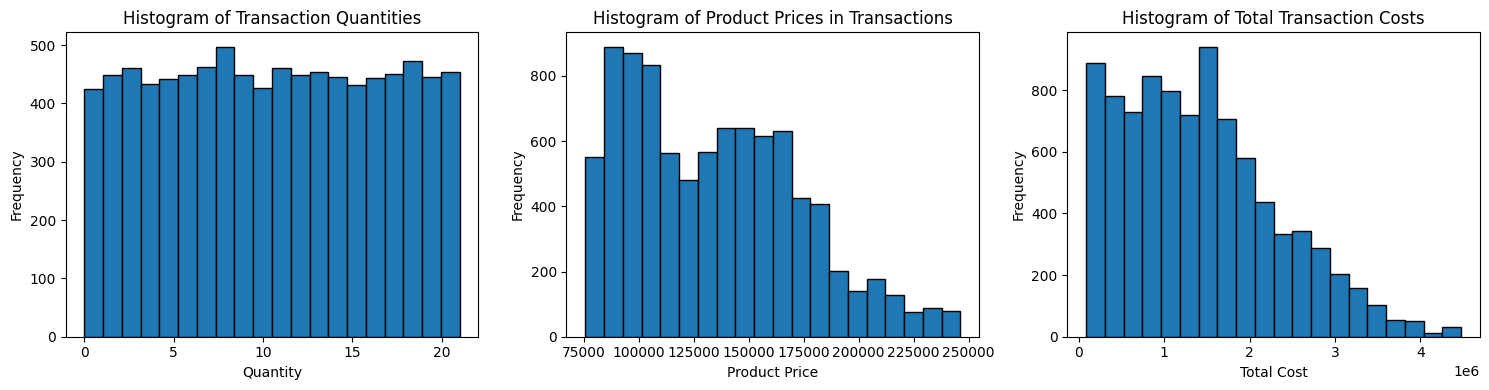

In [66]:
# Create a single figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# Histogram for Quantity
axes[0].hist(transactions['Quantity'], bins=20, edgecolor='black')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of Transaction Quantities')

# Histogram for Product Price
axes[1].hist(transactions['Product_Price'], bins=20, edgecolor='black')
axes[1].set_xlabel('Product Price')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of Product Prices in Transactions')

# Histogram for Total Cost
axes[2].hist(transactions['Total_Cost'], bins=20, edgecolor='black')
axes[2].set_xlabel('Total Cost')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Histogram of Total Transaction Costs')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

### **Why Simple Mean/Median/Mode Imputation is Not Enough**  

The histograms show that **Quantity is evenly distributed**, **Product Price is right-skewed**, and **Total Cost follows the same skewed pattern as price**. Using a **mean or median** to fill missing values would distort the data:  

- **Quantity:** No clear central value, so a mean or median would not reflect actual purchase behavior. Instead, fill based on `Product_ID` or `Company_ID` trends.  
- **Product Price:** Skewed distribution means a mean would overestimate, and a median would ignore high-value products. Use **closest available product price** instead.  
- **Total Cost:** Since `Total_Cost = Product_Price × Quantity`, missing values should be **recalculated directly** instead of imputed with a single value.  

### **Best Approach for Handling Missing Values**  
✔ Use **`Product_ID` to infer `Product_Price`** instead of an average.  
✔ Find the **closest product price match** instead of a global median.  
✔ **Recalculate `Total_Cost`** rather than imputing it.  

This ensures missing values are filled **accurately** while maintaining **data integrity**.

### **Filling in `Product_ID`**

The general first step is to fill in `Product_ID` because all other data points are tied to it. The `Product_ID` serves as a key that links data such as `Product_Price` to the `products_data`. By ensuring that the `Product_ID` is correctly filled, it establishes the foundation for correctly linking the product data with other details in the dataset.

In this first step, the process involves using the available `Product_Price` to infer the missing `Product_ID`. For each missing `Product_ID`, the closest `Product_Price` is identified from the `products_data` and used to fill the missing values. This step ensures that the `Product_ID` is populated with the correct values, enabling accurate mapping between the `Product_Price` and `Product_ID`.

Once the `Product_ID` is filled, it enables the accurate interpretation of the remaining data, such as `Quantity` and `Total_Cost`, making it possible to proceed with further steps for imputing other missing values.

#### **Explanation for Step 1:**

In **Step 1**, we are attempting to fill in missing `Product_ID` values based on the available `Product_Price` in the `transactions` dataset.

- **Approach**:
    - We define a function `find_closest_price()` that compares the `Product_Price` from each transaction with the prices in the `products` dataset and finds the closest match by computing the absolute difference.
    - If a `Product_ID` is missing but a `Product_Price` is available, we use this function to find the closest `Product_Price` in the `products` dataset and fill in the `Product_ID` accordingly.

- **Outcome**:
    - The missing `Product_ID` values are filled by finding the closest match for the `Product_Price`. This helps to ensure that `Product_ID` is filled accurately where possible.
    - After filling, we check for remaining missing values in `Product_ID`.

### **Code Explanation for Step 1**:
```python
filled_count = 0
for idx, row in transactions[transactions["Product_ID"].isnull() & transactions["Product_Price"].notnull()].iterrows():
    price = row["Product_Price"]
    
    # Get the closest Product_Price from products_df
    closest_product = find_closest_price(price, products)
    
    if closest_product is not None:
        transactions.at[idx, "Product_ID"] = closest_product["Product_ID"]
        filled_count += 1
```
- This part loops through rows where `Product_ID` is missing but `Product_Price` is available, then uses the `find_closest_price` function to find the closest `Product_Price` from `products` and fills in the corresponding `Product_ID`.
- The count of filled rows is tracked with `filled_count`, and we print the number of rows filled and the remaining missing values in `Product_ID`.

### **Output**:
This step provides an updated `Product_ID` for missing values, and the next step will use the **calculated** product prices (if `Product_Price` is missing) to fill in `Product_ID`.


In [67]:
import pandas as pd
import numpy as np

# Assuming products is your DataFrame with Product_Price and Product_ID
# Let's define a function to get the closest price

def find_closest_price(price, products_df):
    # Exclude the problematic price 151,200.00
    if price == 151200.00:
        print(f"Skipping price {price} because it's flagged.")
        return None

    # Find the closest price
    closest_price = products_df.iloc[(products_df['Product_Price'] - price).abs().argmin()]
    return closest_price

# Fill Product_ID using closest Product_Price
filled_count = 0
for idx, row in transactions[transactions["Product_ID"].isnull() & transactions["Product_Price"].notnull()].iterrows():
    price = row["Product_Price"]

    # Get the closest Product_Price from products_df
    closest_product = find_closest_price(price, products)

    if closest_product is not None:
        transactions.at[idx, "Product_ID"] = closest_product["Product_ID"]
        filled_count += 1

print(f"Filled in {filled_count} rows from Product_Price to Product_ID")

# Check remaining missing values in Product_ID
remaining_missing = transactions["Product_ID"].isnull().sum()
print(f"Remaining missing values in Product_ID: {remaining_missing}")

# Print the rows with missing Product_ID (whole row)
missing_rows = transactions[transactions["Product_ID"].isnull()]
print("\nRows with missing Product_ID:")
print(missing_rows)  # Displaying the full row for each missing Product_ID


Filled in 895 rows from Product_Price to Product_ID
Remaining missing values in Product_ID: 105

Rows with missing Product_ID:
      Transaction_ID  Company_ID  Product_ID  Quantity Transaction_Date  \
52              53.0        40.0         NaN      17.0       2021-10-24   
95              96.0        20.0         NaN       4.0       2023-06-02   
125            126.0        29.0         NaN       NaN       2023-09-22   
282            283.0        28.0         NaN      13.0       2022-02-26   
434            435.0        74.0         NaN       2.0       2022-10-31   
...              ...         ...         ...       ...              ...   
9637          9638.0        61.0         NaN       7.0       2024-07-21   
9678          9679.0        18.0         NaN       0.0       2024-07-18   
9906          9907.0        47.0         NaN       6.0       2024-02-28   
9959          9960.0        47.0         NaN      19.0       2022-03-18   
9961          9962.0         1.0         NaN    

#### **Explanation for Step 2:**

**Step 2** focuses on filling in `Product_ID` when `Product_Price` is missing. Instead of directly using the missing `Product_Price`, we calculate it from `Total_Cost` and `Quantity` using the formula `Product_Price = Total_Cost / Quantity`.

- **Approach**:
    - First, we calculate the missing `Product_Price` by dividing `Total_Cost` by `Quantity` for the rows where `Product_Price` is missing but `Total_Cost` and `Quantity` are available.
    - Then, just like in Step 1, we use the newly calculated `Product_Price` to find the closest `Product_ID` from the `products` dataset using the `find_closest_price()` function.

- **Outcome**:
    - The missing `Product_ID` values are filled using the `Calculated_Product_Price`, ensuring that we make use of available data when `Product_Price` is missing.
    - After filling, we again check for remaining missing `Product_ID` values.

### **Code Explanation for Step 2**:
```python
# Step 1: Calculate Product_Price using Total_Cost / Quantity if Product_Price is missing
transactions['Calculated_Product_Price'] = np.nan

# Calculate Product_Price for rows where it's missing, using Total_Cost and Quantity
transactions.loc[transactions['Product_Price'].isnull() & transactions['Total_Cost'].notnull() & transactions['Quantity'].notnull(), 'Calculated_Product_Price'] = \
    transactions['Total_Cost'] / transactions['Quantity']

# Step 2: Fill Product_ID using the calculated Product_Price
filled_count = 0
for idx, row in transactions[transactions["Product_ID"].isnull() & transactions["Calculated_Product_Price"].notnull()].iterrows():
    price = row["Calculated_Product_Price"]
    
    # Get the closest Product_Price from products_df
    closest_product = find_closest_price(price, products)
    
    if closest_product is not None:
        transactions.at[idx, "Product_ID"] = closest_product["Product_ID"]
        filled_count += 1
```

- This code calculates `Product_Price` for rows where it is missing, using the formula `Product_Price = Total_Cost / Quantity`. Then it fills in the missing `Product_ID` by finding the closest match based on the newly calculated `Product_Price`.
  
### **Final Output**:
- After this step, `Product_ID` is filled for rows with missing values using the calculated `Product_Price`. The missing rows are displayed in a tabular format using `tabulate`, making it easy to check the missing values.

In [68]:
import pandas as pd
import numpy as np
from tabulate import tabulate

# Assuming products is your DataFrame with Product_Price and Product_ID
# Let's define a function to get the closest price

def find_closest_price(price, products_df):
    # Find the closest price
    closest_price = products_df.iloc[(products_df['Product_Price'] - price).abs().argmin()]
    return closest_price

# Step 1: Calculate Product_Price using Total_Cost / Quantity if Product_Price is missing
transactions['Calculated_Product_Price'] = np.nan

# Calculate Product_Price for rows where it's missing, using Total_Cost and Quantity
transactions.loc[transactions['Product_Price'].isnull() & transactions['Total_Cost'].notnull() & transactions['Quantity'].notnull(), 'Calculated_Product_Price'] = \
    transactions['Total_Cost'] / transactions['Quantity']

# Step 2: Fill Product_ID using the calculated Product_Price
filled_count = 0
for idx, row in transactions[transactions["Product_ID"].isnull() & transactions["Calculated_Product_Price"].notnull()].iterrows():
    price = row["Calculated_Product_Price"]

    # Get the closest Product_Price from products_df
    closest_product = find_closest_price(price, products)

    if closest_product is not None:
        transactions.at[idx, "Product_ID"] = closest_product["Product_ID"]
        filled_count += 1

print(f"Filled in {filled_count} rows from Calculated_Product_Price to Product_ID")

# Check remaining missing values in Product_ID
remaining_missing = transactions["Product_ID"].isnull().sum()
print(f"Remaining missing values in Product_ID: {remaining_missing}")

# Display the rows with missing Product_ID in a tabular format
missing_rows = transactions[transactions["Product_ID"].isnull()]
missing_rows = missing_rows[['Transaction_ID', 'Company_ID', 'Product_ID',  'Product_Price', 'Product_Price', 'Quantity', 'Total_Cost', 'Calculated_Product_Price']]

# Print the missing rows using tabulate for a nice table format
print("\nRows with missing Product_ID:")
print(tabulate(missing_rows, headers='keys', tablefmt='pretty', showindex=False))


Filled in 80 rows from Calculated_Product_Price to Product_ID
Remaining missing values in Product_ID: 25

Rows with missing Product_ID:
+----------------+------------+------------+---------------+---------------+----------+------------+--------------------------+
| Transaction_ID | Company_ID | Product_ID | Product_Price | Product_Price | Quantity | Total_Cost | Calculated_Product_Price |
+----------------+------------+------------+---------------+---------------+----------+------------+--------------------------+
|     126.0      |    29.0    |    nan     |      nan      |      nan      |   nan    | 1433600.0  |           nan            |
|     1165.0     |    36.0    |    nan     |      nan      |      nan      |   14.0   |    nan     |           nan            |
|     1232.0     |    37.0    |    nan     |      nan      |      nan      |   nan    |    nan     |           nan            |
|     1298.0     |    28.0    |    nan     |      nan      |      nan      |   13.0   |    nan  

#### **Explanation for Step 3:**

**Step 3** focuses on filling missing `Product_ID` values by leveraging `Company_ID`. This step assumes that each company sells a specific set of products, and it uses the most common `Product_ID` associated with a `Company_ID` to fill the missing `Product_ID` values.

- **Approach**:
    1. **Analyze the most common `Product_ID` for each `Company_ID`**:  
       The `groupby('Company_ID')` operation groups the transactions by `Company_ID` and applies `mode()` to identify the most frequent `Product_ID` for each company. This is stored in the `company_product_mapping` dictionary.
    2. **Fill missing `Product_ID` values**:  
       For each row with a missing `Product_ID` and a valid `Company_ID`, the `Product_ID` is filled using the most common `Product_ID` for that `Company_ID`. If a `Product_ID` is available in `company_product_mapping`, it is used to fill in the missing value.
    3. **Track the number of filled rows**:  
       The `filled_count` variable keeps track of how many rows had their `Product_ID` filled.
    4. **Check remaining missing `Product_ID`**:  
       After attempting to fill in `Product_ID`, the code calculates how many `Product_ID` values are still missing and prints the count.

- **Output**:
    - The number of rows filled is displayed.
    - The remaining missing `Product_ID` values are printed.
    - A table of the rows with missing `Product_ID` values is shown, allowing for a detailed review of the missing data.

In [69]:
import pandas as pd
import numpy as np
from tabulate import tabulate

# Step 1: Analyze the most common Product_ID for each Company_ID
company_product_mapping = transactions.groupby('Company_ID')['Product_ID'].apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan).to_dict()

# Step 2: Fill missing Product_ID based on Company_ID
filled_count = 0
for idx, row in transactions[transactions['Product_ID'].isnull() & transactions['Company_ID'].notnull()].iterrows():
    company_id = row['Company_ID']
    if company_id in company_product_mapping and pd.notnull(company_product_mapping[company_id]):
        transactions.at[idx, 'Product_ID'] = company_product_mapping[company_id]
        filled_count += 1

print(f"Filled in {filled_count} rows using Company_ID to infer Product_ID")

# Check remaining missing values in Product_ID
remaining_missing = transactions["Product_ID"].isnull().sum()
print(f"Remaining missing values in Product_ID: {remaining_missing}")

# Display the rows with missing Product_ID in a tabular format
missing_rows = transactions[transactions["Product_ID"].isnull()]
missing_rows = missing_rows[['Transaction_ID', 'Company_ID', 'Product_Price', 'Quantity', 'Total_Cost', 'Calculated_Product_Price']]

# Print the missing rows using tabulate for a nice table format
print("\nRows with missing Product_ID:")
print(tabulate(missing_rows, headers='keys', tablefmt='pretty', showindex=False))


Filled in 23 rows using Company_ID to infer Product_ID
Remaining missing values in Product_ID: 2

Rows with missing Product_ID:
+----------------+------------+---------------+----------+------------+--------------------------+
| Transaction_ID | Company_ID | Product_Price | Quantity | Total_Cost | Calculated_Product_Price |
+----------------+------------+---------------+----------+------------+--------------------------+
|     4386.0     |    nan     |      nan      |   14.0   |    nan     |           nan            |
|      nan       |    nan     |      nan      |   nan    | 1881600.0  |           nan            |
+----------------+------------+---------------+----------+------------+--------------------------+


#### **Explanation for Step 4:**

The rows with missing `Product_ID` contain several crucial data points that are incomplete, making it difficult to reliably infer the correct `Product_ID`:

- **Missing `Product_Price` and `Calculated_Product_Price`:** These values are essential for identifying the product and calculating the expected price.
- **Missing `Quantity`:** Without the `Quantity`, we cannot apply the formula `Total_Cost / Quantity = Product_Price` to estimate the missing values.
- **Inconsistent Data:** The missing `Product_ID` in combination with missing `Product_Price` and `Quantity` creates a data inconsistency that cannot be easily filled without making assumptions.

Since these data points are critical for accurate analysis and cannot be inferred reliably, these rows will be dropped to maintain data quality and consistency.

In [70]:
# Step 4: Drop remaining rows with missing Product_ID after Step 3
transactions.dropna(subset=['Product_ID'], inplace=True)

# Print the number of rows dropped
rows_dropped = len(transactions) - len(transactions)
print(f"Dropped {rows_dropped} rows with missing Product_ID")

# Check if there are any remaining missing Product_IDs
remaining_missing = transactions["Product_ID"].isnull().sum()
print(f"Remaining missing values in Product_ID: {remaining_missing}")

# If there are still missing Product_ID values, print them in a tabular format
if remaining_missing > 0:
    missing_rows = transactions[transactions["Product_ID"].isnull()]
    print("\nRows with remaining missing Product_ID:")
    print(tabulate(missing_rows, headers='keys', tablefmt='pretty', showindex=False))
else:
    print("\nNo missing Product_ID values remain.")


Dropped 0 rows with missing Product_ID
Remaining missing values in Product_ID: 0

No missing Product_ID values remain.


### Replacing Product Price with Correct Data

 Since manual checking reveals that the `Product_Price` values don't match any data in the `products` dataset, the goal is to completely replace the `Product_Price` column in the `transactions` dataset with the correct data from the `products` dataset based on the `Product_ID`.


 **Steps:**
1. **Map `Product_ID` to `Product_Price` from the `products` dataset**.
2. **Replace the entire `Product_Price` column** in `transactions` with the correct values.

In [71]:
# Step 1: Map Product_ID to Product_Price from the products dataset
product_prices_map = products.set_index("Product_ID")["Product_Price"].to_dict()

# Step 2: Replace the entire Product_Price column in transactions with the correct values from products dataset
transactions['Product_Price'] = transactions['Product_ID'].map(product_prices_map)

# Print the number of rows where Product_Price was replaced
filled_count = transactions['Product_Price'].isnull().sum()  # Count how many values are still missing
print(f"Replaced Product_Price for rows: {len(transactions) - filled_count} rows")

# Check remaining missing values in Product_Price
remaining_missing = transactions["Product_Price"].isnull().sum()
print(f"Remaining missing values in Product_Price: {remaining_missing}")

# If there are still missing Product_Price values, print them in a tabular format
if remaining_missing > 0:
    missing_rows = transactions[transactions["Product_Price"].isnull()]
    print("\nRows with remaining missing Product_Price:")
    print(tabulate(missing_rows, headers='keys', tablefmt='pretty', showindex=False))
else:
    print("\nNo missing Product_Price values remain.")


Replaced Product_Price for rows: 9998 rows
Remaining missing values in Product_Price: 0

No missing Product_Price values remain.


### **Imputing Quantity**

If both `Total_Cost` and `Product_Price` are available, we can directly compute the `Quantity` by dividing `Total_Cost` by `Product_Price`. Afterward, we can round the result to the nearest whole number.

### **Step 1: Infer `Quantity` from `Total_Cost` and `Product_Price`**

1. **Formula**:  
   If both `Total_Cost` and `Product_Price` are available and `Quantity` is missing, we can compute the `Quantity` as:

  Quantity = $\frac{\text{Total_Cost}}{\text{Product_Price}}$


   2. **Rounding**:  
   Since `Quantity` must be a whole number, we'll round the result of the division to the nearest integer.

In [72]:
# Step 1: Infer Quantity from Total_Cost and Product_Price if Quantity is missing
transactions['Quantity'] = np.where(
    transactions['Quantity'].isnull() & transactions['Total_Cost'].notnull() & transactions['Product_Price'].notnull(),
    np.round(transactions['Total_Cost'] / transactions['Product_Price']),
    transactions['Quantity']  # Keep the existing value if already present
)

# Ensure Quantity is a whole number
transactions['Quantity'] = transactions['Quantity'].astype('Int64')

# Check how many values are still missing in Quantity
remaining_missing_quantity = transactions["Quantity"].isnull().sum()
print(f"Remaining missing values in Quantity: {remaining_missing_quantity}")

# If there are still missing Quantity values, print them in a tabular format
if remaining_missing_quantity > 0:
    missing_quantity_rows = transactions[transactions["Quantity"].isnull()]
    print("\nRows with remaining missing Quantity:")
    print(tabulate(missing_quantity_rows, headers='keys', tablefmt='pretty', showindex=False))
else:
    print("\nNo missing Quantity values remain.")


Remaining missing values in Quantity: 104

Rows with remaining missing Quantity:
+----------------+------------+------------+----------+---------------------+---------------+------------+--------------------------+
| Transaction_ID | Company_ID | Product_ID | Quantity |  Transaction_Date   | Product_Price | Total_Cost | Calculated_Product_Price |
+----------------+------------+------------+----------+---------------------+---------------+------------+--------------------------+
|      59.0      |    54.0    |    1.0     |   <NA>   | 2021-07-19 00:00:00 |   140000.0    |    nan     |           nan            |
|      79.0      |    66.0    |    4.0     |   <NA>   | 2023-09-14 00:00:00 |   123200.0    |    nan     |           nan            |
|     358.0      |    80.0    |    18.0    |   <NA>   | 2024-06-25 00:00:00 |   134400.0    |    nan     |           nan            |
|     497.0      |    64.0    |    9.0     |   <NA>   | 2022-10-19 00:00:00 |   112000.0    |    nan     |         

#### **Dropping Remaining Rows with Missing `Quantity`:**

The dataset has **8 rows with missing `Quantity` values**. However, these rows also have several other critical pieces of data missing, such as `Company_ID`, `Product_Price`, and `Total_Cost`, which are necessary for calculating or inferring the `Quantity` (e.g., using the formula `Quantity = Total_Cost / Product_Price`). Due to the lack of these critical data points, it is not possible to reliably infer the missing `Quantity`.

Since these rows cannot be filled accurately due to the missing information, they will be **dropped from the dataset** to maintain data integrity. This will ensure that only rows with sufficient data for analysis remain in the dataset.

This step ensures that the analysis is based on complete and reliable data, minimizing the risk of errors or assumptions in the results.

In [73]:
# Step 1: Drop rows with remaining missing Quantity
transactions.dropna(subset=['Quantity'], inplace=True)

# Step 2: Check if there are still missing values in Quantity
remaining_missing_quantity = transactions["Quantity"].isnull().sum()

# Step 3: Print a message if there are still missing Quantity values
if remaining_missing_quantity > 0:
    print(f"There are still {remaining_missing_quantity} rows with missing Quantity.")
    missing_rows = transactions[transactions["Quantity"].isnull()]
    print("\nRows with remaining missing Quantity:")
    print(missing_rows)  # Display the rows with missing Quantity
else:
    print("No missing Quantity values remain.")
    print(f"Total rows with valid Quantity: {len(transactions)}")


No missing Quantity values remain.
Total rows with valid Quantity: 9894


### **Replacing the `Total_Cost` Column:**

In this step, we are **replacing the entire `Total_Cost` column** to ensure data integrity in the dataset. The `Total_Cost` column was originally either missing or incorrect in some rows, and in some cases, it did not reflect the true product cost based on `Quantity` and `Product_Price`.

To maintain data integrity, we calculated the correct `Total_Cost` by multiplying the **`Quantity`** by the **`Product_Price`** for each row. This calculation ensures that the `Total_Cost` is accurate and consistent with the other data in the dataset.

- **Why replace the entire column?**
   - The `Total_Cost` column needs to reflect the correct cost for each product based on its quantity and price. Simply filling in the missing values would not ensure consistency across all rows. Replacing the entire column guarantees that every row has an accurate and uniform `Total_Cost` value.

- **Outcome**:
   - After this step, the `Total_Cost` column will be completely filled with the correct values, improving the overall quality and accuracy of the data, and making the dataset suitable for further analysis or modeling.

In [74]:
# Step 1: Drop the Calculated_Product_Price and Total_Cost columns
transactions.drop(columns=['Calculated_Product_Price'], inplace=True)

# Step 2: Replace the entire Total_Cost column with the correct values (Quantity * Product_Price)
transactions['Total_Cost'] = transactions['Quantity'] * transactions['Product_Price']

# Print the first few rows to confirm changes
print("\nFirst few rows after dropping Calculated_Product_Price and updating Total_Cost:")
print(tabulate(transactions.head(), headers='keys', tablefmt='pretty', showindex=False))

# Confirm no missing values in Total_Cost
remaining_missing_total_cost = transactions["Total_Cost"].isnull().sum()
print(f"\nRemaining missing values in Total_Cost: {remaining_missing_total_cost}")



First few rows after dropping Calculated_Product_Price and updating Total_Cost:
+----------------+------------+------------+----------+---------------------+---------------+------------+
| Transaction_ID | Company_ID | Product_ID | Quantity |  Transaction_Date   | Product_Price | Total_Cost |
+----------------+------------+------------+----------+---------------------+---------------+------------+
|      1.0       |    88.0    |    6.0     |    6     | 2024-03-26 00:00:00 |   179200.0    | 1075200.0  |
|      2.0       |    29.0    |    19.0    |    16    | 2024-07-09 00:00:00 |    95200.0    | 1523200.0  |
|      nan       |    28.0    |    18.0    |    6     | 2024-04-13 00:00:00 |   134400.0    |  806400.0  |
|      4.0       |    85.0    |    12.0    |    12    | 2023-09-06 00:00:00 |    84000.0    | 1008000.0  |
|      5.0       |    47.0    |    3.0     |    8     | 2021-07-06 00:00:00 |   100800.0    |  806400.0  |
+----------------+------------+------------+----------+--------

### **Filling Missing `Company_ID`:**

To fill in the missing `Company_ID` values, we need to explore how to infer them based on the available data. Specifically, you are asking if `Product_Price` and `Quantity` can help us infer the missing `Company_ID`.



1. **Analyze the Missing `Company_ID`**:  
   First, let's check how many `Company_ID` values are missing and identify the rows with missing `Company_ID`.

2. **Check if `Product_Price` and `Quantity` Can Help**:  
   Since `Product_Price` and `Quantity` are tied to a specific product and company, we can:
   - **Group by `Product_Price` and `Quantity`** to see if there are patterns.
   - If a specific combination of `Product_Price` and `Quantity` is frequently associated with a particular `Company_ID`, we can use that information to infer missing `Company_ID` values.

3. **Fill `Company_ID` Based on Frequent Combinations**:  
   If there is a consistent `Company_ID` for a given combination of `Product_Price` and `Quantity`, we can assign the most frequent `Company_ID` for that combination to fill in the missing values.

In [75]:
# Step 1: Check how many Company_ID values are missing
missing_company_id = transactions["Company_ID"].isnull().sum()
print(f"Missing values in Company_ID: {missing_company_id}")

# Step 2: Fill missing Company_ID based on the most frequent Company_ID for each Product_Price and Quantity combination
filled_count = 0
for idx, row in transactions[transactions['Company_ID'].isnull() & transactions['Product_Price'].notnull() & transactions['Quantity'].notnull()].iterrows():
    price = row['Product_Price']
    quantity = row['Quantity']

    # Find the most frequent Company_ID for this combination of Product_Price and Quantity
    most_frequent_company_id = transactions[(transactions['Product_Price'] == price) & (transactions['Quantity'] == quantity)]['Company_ID'].mode()

    if not most_frequent_company_id.empty:
        # Fill the missing Company_ID with the most frequent one
        transactions.at[idx, 'Company_ID'] = most_frequent_company_id[0]
        filled_count += 1

# Print the number of rows where Company_ID was filled
print(f"Filled in {filled_count} rows for Company_ID using Product_Price and Quantity")

# Step 3: Check remaining missing values in Company_ID
remaining_missing_company_id = transactions["Company_ID"].isnull().sum()
print(f"Remaining missing values in Company_ID: {remaining_missing_company_id}")

# If there are still missing Company_ID values, print them in a tabular format
if remaining_missing_company_id > 0:
    missing_company_id_rows = transactions[transactions["Company_ID"].isnull()]
    print("\nRows with remaining missing Company_ID:")
    print(tabulate(missing_company_id_rows, headers='keys', tablefmt='pretty', showindex=False))
else:
    print("\nNo missing Company_ID values remain.")


Missing values in Company_ID: 991
Filled in 991 rows for Company_ID using Product_Price and Quantity
Remaining missing values in Company_ID: 0

No missing Company_ID values remain.


### **Fill Missing `Transaction_ID`:**

1. **Check the Existing `Transaction_ID`**:  
   First, we'll check if the existing `Transaction_ID` values are sequential and have a consistent pattern.
   
2. **Identify the Range of `Transaction_ID`**:  
   We'll check the minimum and maximum values in the `Transaction_ID` column to determine the expected range (i.e., 1 to N, where N is the total number of rows).

3. **Fill Missing `Transaction_ID` Using the Pattern**:  
   If `Transaction_ID` is missing, we can fill the missing values by generating a sequence of numbers starting from 1, based on the existing range.

In [76]:
import pandas as pd
import numpy as np

# Step 1: Check if Transaction_ID follows a sequential pattern
transaction_id_pattern_check = transactions['Transaction_ID'].dropna().astype(int).sort_values()

# Print the first few rows of the existing Transaction_ID to check the pattern
print("\nExisting Transaction_ID pattern (sorted):")
print(transaction_id_pattern_check.head())

# Step 2: Identify the range of Transaction_ID (check the minimum and maximum values)
min_id = transaction_id_pattern_check.min()
max_id = transaction_id_pattern_check.max()
print(f"\nExpected range of Transaction_ID: {min_id} to {max_id}")

# Step 3: Check if the IDs are sequential and there are gaps
expected_ids = set(range(min_id, max_id + 1))
actual_ids = set(transaction_id_pattern_check)

# Identify missing Transaction_IDs
missing_ids = expected_ids - actual_ids
print(f"\nMissing Transaction_IDs: {sorted(missing_ids)}")

# Step 4: Fill missing Transaction_IDs by generating the missing sequence
transaction_id_filled = transaction_id_pattern_check.copy()

# For rows with missing Transaction_ID, fill them with the missing values
for idx in transactions[transactions["Transaction_ID"].isnull()].index:
    if missing_ids:
        # Get the first missing ID and remove it from the set
        missing_id = min(missing_ids)
        transactions.at[idx, "Transaction_ID"] = missing_id
        missing_ids.remove(missing_id)

# Step 5: Check if any missing Transaction_IDs remain
remaining_missing = transactions["Transaction_ID"].isnull().sum()
print(f"\nRemaining missing values in Transaction_ID: {remaining_missing}")

# Display the updated rows
if remaining_missing == 0:
    print("\nAll missing Transaction_ID values have been filled.")
else:
    missing_rows = transactions[transactions["Transaction_ID"].isnull()]
    print("\nRows with remaining missing Transaction_ID:")
    print(missing_rows)



Existing Transaction_ID pattern (sorted):
0    1
1    2
3    4
4    5
5    6
Name: Transaction_ID, dtype: int64

Expected range of Transaction_ID: 1 to 9999

Missing Transaction_IDs: [3, 18, 22, 26, 56, 59, 60, 68, 79, 83, 109, 139, 150, 156, 162, 176, 180, 195, 203, 207, 216, 219, 234, 241, 245, 248, 255, 258, 271, 282, 293, 297, 305, 307, 341, 358, 368, 373, 393, 407, 409, 410, 412, 443, 444, 456, 472, 482, 489, 491, 492, 496, 497, 498, 507, 536, 540, 541, 543, 559, 560, 568, 582, 586, 592, 594, 607, 610, 623, 624, 628, 637, 676, 692, 713, 718, 739, 744, 745, 746, 757, 769, 771, 812, 814, 830, 870, 880, 888, 894, 921, 928, 930, 936, 959, 962, 971, 993, 1018, 1033, 1052, 1058, 1064, 1088, 1089, 1095, 1102, 1103, 1114, 1121, 1123, 1125, 1149, 1168, 1170, 1183, 1189, 1207, 1211, 1212, 1232, 1238, 1240, 1244, 1270, 1279, 1313, 1318, 1320, 1321, 1328, 1340, 1344, 1358, 1368, 1373, 1376, 1382, 1390, 1399, 1402, 1417, 1419, 1443, 1444, 1445, 1453, 1463, 1475, 1486, 1489, 1492, 1494, 1495, 

### **Converting `Transaction` Data Types**

**📌 Why Change Data Types?**  
Proper data types are essential for **efficient processing, accurate computations, and machine learning readiness**. The following changes ensure that the **`transactions` dataset is correctly structured**:

| Column Name        | Current Data Type | Correct Data Type | Reason |
|--------------------|-------------------|-------------------|--------|
| **Transaction_ID** | `float64`          | `int64`            | Transaction IDs should be integers for indexing and as primary keys (PKs). |
| **Company_ID**     | `float64`          | `int64`            | Company IDs should be integers as they are foreign keys (FKs). |
| **Product_ID**     | `float64`          | `int64`            | Product IDs should be integers for indexing and data integrity. |
| **Quantity**       | `int64`            | `int64`            | No change, as `Quantity` is already an integer (representing number of units). |
| **Transaction_Date** | `datetime64`    | `datetime64`       | No change, as dates are already in the correct format for analysis. |
| **Product_Price**  | `float64`          | `float64`          | No change, as `Product_Price` is already in the correct format (currency as float). |
| **Total_Cost**     | `float64`          | `float64`          | No change, as `Total_Cost` is a numeric column representing cost. |

</br>

**📌 Key Decisions Explained**

- **Convert `Transaction_ID`, `Company_ID`, and `Product_ID` to `int64`**  
  - **Why?** These columns are **primary and foreign keys** for relational integrity. They should be integers for indexing and efficient lookups.
  
- **Keep `Quantity` as `int64`**  
  - **Why?** `Quantity` is already an integer type, representing the number of units, and does not require conversion.

- **Keep `Transaction_Date` as `datetime64`**  
  - **Why?** Dates are already in the correct format, and no conversion is needed.

- **Keep `Product_Price` and `Total_Cost` as `float64`**  
  - **Why?** These columns represent currency and need to remain as floating-point numbers for numerical calculations (e.g., summing costs, averaging prices).

</br>

**🚀 Final Takeaways**

✔ **Ensures `Transaction_ID`, `Company_ID`, and `Product_ID` are correctly formatted for relational integrity.**  
✔ **Prepares the `Quantity`, `Product_Price`, and `Total_Cost` columns for numerical computations.**  
✔ **Maintains `Transaction_Date` as a date type for time-based analysis.**  
✔ **Optimizes the dataset for machine learning and data processing.**

In [77]:
# Step 1: Convert Transaction_ID, Company_ID, and Product_ID to integer type (int)
transactions['Transaction_ID'] = transactions['Transaction_ID'].astype('Int64')  # Use 'Int64' to handle missing values (nullable integers)
transactions['Company_ID'] = transactions['Company_ID'].astype('Int64')  # Nullable integer
transactions['Product_ID'] = transactions['Product_ID'].astype('Int64')  # Nullable integer

# Step 2: Ensure Product_Price and Total_Cost are float type
transactions['Product_Price'] = transactions['Product_Price'].astype('float64')
transactions['Total_Cost'] = transactions['Total_Cost'].astype('float64')

# Step 3: Verify the changes by checking the data types
print("\nUpdated Data Types:")
print(transactions.dtypes)


Updated Data Types:
Transaction_ID               Int64
Company_ID                   Int64
Product_ID                   Int64
Quantity                     Int64
Transaction_Date    datetime64[ns]
Product_Price              float64
Total_Cost                 float64
dtype: object


In [78]:


# Assuming 'transactions' is your DataFrame
for col in transactions.columns:
    print(col) # This line needs to be indented

Transaction_ID
Company_ID
Product_ID
Quantity
Transaction_Date
Product_Price
Total_Cost


## Merging Data

In [79]:
# Step 1: Merge transactions with customers based on Company_ID
transactions_with_customers = pd.merge(transactions, customers, on='Company_ID', how='left')

# Step 2: Merge the resulting DataFrame with products based on Product_ID
final_df = pd.merge(transactions_with_customers, products, on='Product_ID', how='left', suffixes=('_transaction', '_product'))

# Step 3: Remove the duplicate Product_Price column from transactions (if any)
final_df['Product_Price'] = final_df['Product_Price_product']  # Prioritize correct price from the products dataset
final_df.drop(columns=['Product_Price_transaction', 'Product_Price_product'], inplace=True)  # Drop the extra columns

# Step 4: Verify the final merged DataFrame
final_df


,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Total_Cost,Company_Name,Company_Profit,Address,Product_Name,Product_Price
0,1,88,6,6,2024-03-26,1075200.0,Elite Consulting 88,75950.0,"EDSA, Brgy. 456, Taguig, Philippines",RevenueVue Dashboard,179200.0
1,2,29,19,16,2024-07-09,1523200.0,Sky Industries 29,61952.0,"EDSA, Brgy. 606, Makati, Philippines",EcoNomix Modeler,95200.0
2,3,28,18,6,2024-04-13,806400.0,Global Holdings 28,61115.0,"Katipunan Ave., Brgy. 303, Taguig, Philippines",DashSync Analytics Hub,134400.0
3,4,85,12,12,2023-09-06,1008000.0,Green Ventures 85,113470.0,"EDSA, Brgy. 707, Cebu City, Philippines",BudgetMaster Pro,84000.0
4,5,47,3,8,2021-07-06,806400.0,Green Industries 47,31130.0,"Taft Ave., Brgy. 707, Mandaluyong, Philippines",TrendWise Forecaster,100800.0
...,...,...,...,...,...,...,...,...,...,...,...
9889,8942,30,10,7,2022-06-05,627200.0,Quantum Holdings 30,35620.0,"EDSA, Brgy. 789, Pasig, Philippines",SegmentX Targeting,89600.0
9890,9997,39,2,9,2021-05-17,1512000.0,Prime Consulting 39,107255.0,"Ortigas Ave., Brgy. 606, Davao City, Philippines",MarketMinder Analytics,168000.0
9891,8944,90,1,15,2022-07-19,2100000.0,Prime Holdings 90,46225.0,"EDSA, Brgy. 202, Parañaque, Philippines",FinPredictor Suite,140000.0
9892,9999,33,5,19,2021-04-15,1596000.0,Green Consulting 33,52003.0,"Shaw Blvd., Brgy. 707, Mandaluyong, Philippines",SalesSync Optimizer,84000.0
